In [ ]:
# Import Library
import os
import sys
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
    pairwise_distances
)

from google.colab import drive
drive.mount('/content/drive')

# Set Library
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 120

OUTPUT_DIR = "outputKmeans"
os.makedirs(OUTPUT_DIR, exist_ok=True)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("[INFO] Library berhasil diinstall.")
print(f"[INFO] Folder output: '{OUTPUT_DIR}' | Random state: {RANDOM_STATE}")

Mounted at /content/drive
[INFO] Library berhasil diinstall.
[INFO] Folder output: 'outputKmeans' | Random state: 42


In [ ]:
# Load Dataset
df_raw = pd.read_csv('/content/drive/MyDrive/ml-sem5/kuis1/dataset/diabetes_012_health_indicators_BRFSS2015.csv')
print(f"Data awal: {df_raw.shape[0]} baris x {df_raw.shape[1]} kolom")
df_raw.head()

Data awal: 253680 baris x 22 kolom


,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [ ]:
# Cek data awal
print("Tipe data tiap kolom:")
print(df_raw.dtypes.value_counts())

print("\nTotal missing value per kolom (hanya yang > 0):")
missing = df_raw.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "Tidak ada missing value")

print(f"\nJumlah baris duplikat: {df_raw.duplicated().sum()}")

print("\nSebaran kelas Diabetes_012 (0=tidak, 1=pra-diabetes, 2=diabetes):")
print(df_raw['Diabetes_012'].value_counts().sort_index())

Tipe data tiap kolom:
float64    22
Name: count, dtype: int64

Total missing value per kolom (hanya yang > 0):
Tidak ada missing value

Jumlah baris duplikat: 23899

Sebaran kelas Diabetes_012 (0=tidak, 1=pra-diabetes, 2=diabetes):
Diabetes_012
0.0    213703
1.0      4631
2.0     35346
Name: count, dtype: int64


In [ ]:
# Preprocessing
df = df_raw.copy()
n_awal = len(df)

# Buang kelas 1 (pra-diabetes), fokus ke diabetes vs tidak
df = df[df['Diabetes_012'] != 1]
print(f"Setelah buang kelas 1      : {len(df)} baris (terbuang {n_awal - len(df)})")  # laporan jumlah baris setelah kelas 1 dibuang

# Membuang kolom income
df = df.drop(columns=['Income'])
print(f"Setelah buang kolom Income : {df.shape[1]} kolom")

# Menghapus baris duplikat
n_sebelum_dup = len(df)
df = df.drop_duplicates()
print(f"Setelah hapus duplikat     : {len(df)} baris (terbuang {n_sebelum_dup - len(df)})")

# Rapikan nomor baris jadi 0,1,2,... lagi
df = df.reset_index(drop=True)

# Pisahkan tabel fitur dan label
y_label = df['Diabetes_012'].copy()
df_features = df.drop(columns=['Diabetes_012']).astype(float)
print(f"Jumlah fitur untuk klastering: {df_features.shape[1]}")
print(f"Daftar fitur: {list(df_features.columns)}")

# Standardisasi
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_features.values)
print(f"Bentuk data siap klaster: {X_scaled.shape}")
print(f"Cek mean 0 dan std 1: {X_scaled.mean():.4f} / {X_scaled.std():.4f}")
df_features.head()

Setelah buang kelas 1      : 249049 baris (terbuang 4631)
Setelah buang kolom Income : 21 kolom
Setelah hapus duplikat     : 208858 baris (terbuang 40191)
Jumlah fitur untuk klastering: 20
Daftar fitur: ['HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education']
Bentuk data siap klaster: (208858, 20)
Cek mean 0 dan std 1: -0.0000 / 1.0000


,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education
0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0
1,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0
2,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0
3,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0
4,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0


## 5. Penentuan Jumlah Klaster Optimal (Elbow Method)

Hitung SSE (inertia) untuk setiap k dari 1 sampai 10, lalu cari titik siku secara geometris (titik terjauh dari garis lurus yang menghubungkan k=1 dan k=10).

Datanya besar, jadi `n_init=3` dipakai supaya nggak terlalu lama dan nggak bikin Colab gratisan kehabisan RAM/waktu.

  k = 1  | SSE = 4,177,160.0
  k = 2  | SSE = 3,750,599.6
  k = 3  | SSE = 3,543,983.4
  k = 4  | SSE = 3,351,572.7
  k = 5  | SSE = 3,227,182.2
  k = 6  | SSE = 3,075,453.6
  k = 7  | SSE = 2,952,090.7
  k = 8  | SSE = 2,781,094.1
  k = 9  | SSE = 2,743,517.6
  k = 10 | SSE = 2,657,949.0
[ELBOW] Jumlah klaster optimal terdeteksi: k = 4
[SIMPAN] Grafik Elbow disimpan ke: 'outputKmeans/elbow_euclidean.png'


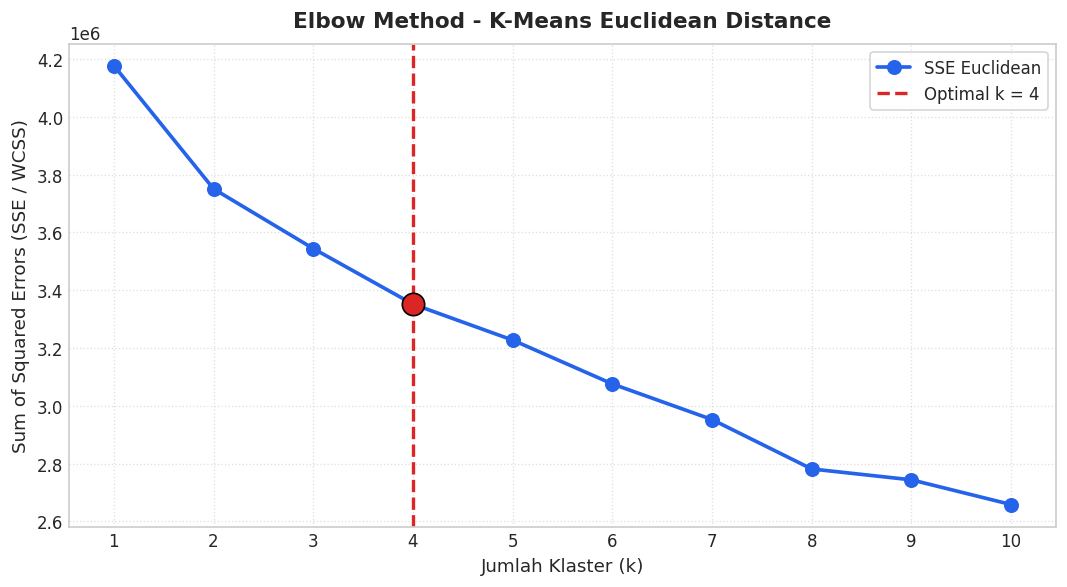

In [ ]:
k_range = list(range(1,11))
sse_euclidean = []

for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=3, random_state=RANDOM_STATE)
    km.fit(X_scaled)
    sse_euclidean.append(km.inertia_)
    print(f"  k = {k:<2} | SSE = {km.inertia_:,.1f}")

def find_elbow_point(k_vals, sses):
  p1 = np.array([k_vals[0], sses[0]])
  p2 = np.array([k_vals[-1], sses[-1]])
  line_vec = p2 - p1
  line_unit = line_vec / np.linalg.norm(line_vec)
  dists = [
      np.linalg.norm((np.array([k, s]) - p1) - np.dot(np.array([k, s]) - p1, line_unit) * line_unit)
      for k, s in zip(k_vals, sses)]
  return k_vals[int(np.argmax(dists))]

optimal_k = find_elbow_point(k_range, sse_euclidean)
print(f"[ELBOW] Jumlah klaster optimal terdeteksi: k = {optimal_k}")

plt.figure(figsize=(9, 5))
plt.plot(k_range, sse_euclidean, marker='o', markersize=8, linewidth=2.2, color='#2563EB', label='SSE Euclidean')  # kurva SSE
plt.axvline(x=optimal_k, color='#DC2626', linestyle='--', linewidth=2, label=f'Optimal k = {optimal_k}')
plt.scatter([optimal_k], [sse_euclidean[optimal_k - 1]], color='#DC2626', s=180, zorder=5, edgecolor='black')
plt.title('Elbow Method - K-Means Euclidean Distance', fontsize=13, fontweight='bold', pad=10)
plt.xlabel('Jumlah Klaster (k)', fontsize=11)              # label sumbu x
plt.ylabel('Sum of Squared Errors (SSE / WCSS)', fontsize=11)  # label sumbu y
plt.xticks(k_range)                                        # tampilkan semua angka k di sumbu x
plt.grid(True, linestyle=':', alpha=0.6)                   # tambah garis bantu tipis
plt.legend(frameon=True, facecolor='white')                # tampilkan legenda
plt.tight_layout()

elbow_path = os.path.join(OUTPUT_DIR, "elbow_euclidean.png")
plt.savefig(elbow_path, dpi=300)
print(f"[SIMPAN] Grafik Elbow disimpan ke: '{elbow_path}'")
plt.show()

## Kelas K-Means Euclidean

In [ ]:
class KMeansEuclidean:
    def __init__(self, n_clusters=3, max_iter=300, tol=1e-4, random_state=42):
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.tol = tol
        self.random_state = random_state
        self.centroids = None
        self.labels_ = None
        self.inertia_ = 0.0
        self.n_iter_ = 0
        self.execution_time_ = 0.0

    def _compute_distance(self, X, centroids):
        # Euclidean distance matrix: ||X - centroids||_2
        return pairwise_distances(X, centroids, metric='euclidean')

    def _init_centroids(self, X):
        rng = np.random.RandomState(self.random_state)
        n_samples, _ = X.shape
        first_idx = rng.randint(n_samples)
        centroids = [X[first_idx]]

        for _ in range(1, self.n_clusters):
            cur_c = np.array(centroids)
            dists = self._compute_distance(X, cur_c)
            min_dists = np.min(dists, axis=1)
            sq_dists = min_dists ** 2
            sum_sq = np.sum(sq_dists)
            probs = np.ones(n_samples) / n_samples if sum_sq == 0 else sq_dists / sum_sq
            next_idx = rng.choice(n_samples, p=probs)
            centroids.append(X[next_idx])
        return np.array(centroids)

    def fit(self, X):
        start_time = time.perf_counter()
        self.centroids = self._init_centroids(X)

        for it in range(self.max_iter):
            self.n_iter_ = it + 1
            # Assignment Step: Penugasan sampel ke centroid Euclidean terdekat
            dists = self._compute_distance(X, self.centroids)
            labels = np.argmin(dists, axis=1)

            # Update Step: Pembaruan posisi centroid menggunakan rata-rata aritmetika (mean)
            new_centroids = np.zeros_like(self.centroids)
            rng = np.random.RandomState(self.random_state)
            for k in range(self.n_clusters):
                cluster_pts = X[labels == k]
                if len(cluster_pts) == 0:
                    new_centroids[k] = X[rng.randint(len(X))]
                else:
                    new_centroids[k] = np.mean(cluster_pts, axis=0)

            # Pengecekan konvergensi pergeseran centroid
            shift = np.linalg.norm(new_centroids - self.centroids)
            self.centroids = new_centroids
            self.labels_ = labels

            if shift < self.tol:
                break

        # Komputasi Nilai Fungsi Objektif SSE: J = sum_{k=1}^K sum_{x in S_k} ||x - mu_k||_2^2
        final_dists = self._compute_distance(X, self.centroids)
        assigned_dists = final_dists[np.arange(len(X)), self.labels_]
        self.inertia_ = float(np.sum(assigned_dists ** 2))
        self.execution_time_ = float(time.perf_counter() - start_time)
        return self

print("[INFO] Kelas KMeansEuclidean berhasil diinisialisasi.")

[INFO] Kelas KMeansEuclidean berhasil diinisialisasi.


In [ ]:
# Membuat Model euclidean dan menjalankan klastering
model_euclidean = KMeansEuclidean(n_clusters=optimal_k, max_iter=300, tol=1e-4, random_state=RANDOM_STATE)
model_euclidean.fit(X_scaled)
labels = model_euclidean.labels_

# Mengambil silhoutte pada 10000 sample
sil_score = float(silhouette_score(X_scaled, labels, metric='euclidean', sample_size=10000, random_state=RANDOM_STATE))
db_score = float(davies_bouldin_score(X_scaled, labels)) # Score Davies-Bouldin (semakin kecil semakin bagus)
ch_score = float(calinski_harabasz_score(X_scaled, labels)) # Score Calinski-Harabasz (semakin besar semakin bagus)

eval_df = pd.DataFrame([{
    'Distance Metric': 'Euclidean Distance (L2)',
    'Optimal k': optimal_k,
    'Jumlah Data': X_scaled.shape[0],
    'Jumlah Fitur': X_scaled.shape[1],
    'Silhouette Score (↑)': round(sil_score, 4),
    'Davies–Bouldin Index (↓)': round(db_score, 4),
    'Calinski–Harabasz Index (↑)': round(ch_score, 2),
    'Execution Time (s) (↓)': round(model_euclidean.execution_time_, 5),
    'Objective Value (SSE) (↓)': round(model_euclidean.inertia_, 2)
}])

print("\n" + "="*80)
print("TABEL EVALUASI K-MEANS EUCLIDEAN")
print("="*80)
print(eval_df.to_string(index=False))
print("="*80)

df_clustered = df_features.copy()
df_clustered['Diabetes_012'] = y_label.values
df_clustered['Cluster_Euclidean'] = labels

profil = df_clustered.groupby('Cluster_Euclidean').mean().round(3)
profil['Jumlah Data'] = df_clustered['Cluster_Euclidean'].value_counts().sort_index()
profil['% Diabetes'] = (df_clustered.groupby('Cluster_Euclidean')['Diabetes_012'].apply(lambda s: (s == 2).mean() * 100)).round(2)

excel_path = os.path.join(OUTPUT_DIR, "evaluasi_kmeans_euclidean.xlsx")

with pd.ExcelWriter(excel_path, engine='openpyxl') as writer:
    eval_df.to_excel(writer, sheet_name='Ringkasan_Evaluasi', index=False)  # sheet 1: ringkasan evaluasi
    profil.to_excel(writer, sheet_name='Profil_Klaster')   # sheet 2: profil rata-rata tiap klaster
print(f"[SIMPAN] Evaluasi & profil klaster disimpan ke: '{excel_path}'")

csv_path = os.path.join(OUTPUT_DIR, "data_terklaster.csv")  # lokasi CSV data terklaster
df_clustered.to_csv(csv_path, index=False)                 # simpan data lengkap + label klaster (CSV, lebih ringan dari Excel)
print(f"[SIMPAN] Data terklaster disimpan ke: '{csv_path}'")


TABEL EVALUASI K-MEANS EUCLIDEAN
        Distance Metric  Optimal k  Jumlah Data  Jumlah Fitur  Silhouette Score (↑)  Davies–Bouldin Index (↓)  Calinski–Harabasz Index (↑)  Execution Time (s) (↓)  Objective Value (SSE) (↓)
Euclidean Distance (L2)          4       208858            20                0.0811                    2.6378                     17124.85                 5.53425                  3352501.3
[SIMPAN] Evaluasi & profil klaster disimpan ke: 'outputKmeans/evaluasi_kmeans_euclidean.xlsx'
[SIMPAN] Data terklaster disimpan ke: 'outputKmeans/data_terklaster.csv'


In [ ]:
# Profile tiap klaster
profil

,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Diabetes_012,Jumlah Data,% Diabetes
Cluster_Euclidean,,,,,,,,,,,,,,,,,,,,,
0,0.847,0.643,0.992,29.518,0.516,0.045,0.147,0.735,0.612,0.781,...,2.622,1.529,1.922,0.112,0.516,9.718,4.921,0.455,73958,22.76
1,0.686,0.613,0.984,31.346,0.621,0.160,0.291,0.441,0.548,0.709,...,3.979,10.105,19.260,0.797,0.364,9.188,4.511,0.688,35502,34.38
2,0.333,0.319,0.860,28.810,0.493,0.025,0.059,0.697,0.568,0.763,...,2.661,4.605,4.064,0.139,0.486,6.116,4.528,0.222,11827,11.09
3,0.062,0.230,0.929,27.244,0.375,0.007,0.010,0.820,0.615,0.820,...,2.120,2.917,1.918,0.033,0.403,6.436,5.237,0.097,87571,4.86


[SIMPAN] Grafik pemetaan klaster disimpan ke: 'outputKmeans/cluster_euclidean.png'


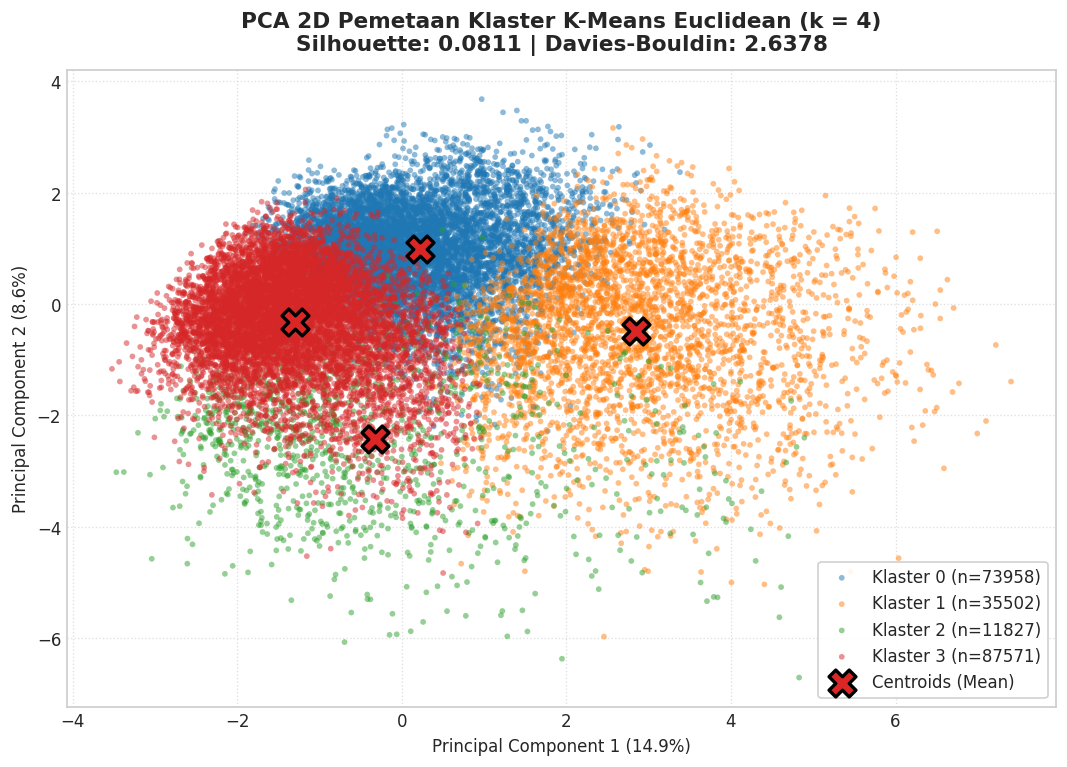

In [ ]:
# 8. VISUALISASI PCA 2D PEMETAAN KLASTER & CENTROIDS
from sklearn.decomposition import PCA
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)                        # ubah data 20 dimensi jadi 2 dimensi
centroids_pca = pca.transform(model_euclidean.centroids)   # proyeksikan centroid ke ruang 2D yang sama

rng_plot = np.random.RandomState(RANDOM_STATE)             # generator acak untuk memilih sampel plot
n_plot = min(20000, len(X_pca))                            # jumlah titik yang digambar (maks 20.000)
idx_plot = rng_plot.choice(len(X_pca), size=n_plot, replace=False)

plt.figure(figsize=(9, 6.5))
palette = sns.color_palette("tab10", optimal_k)

for k in range(optimal_k):
    mask = (labels[idx_plot] == k)
    plt.scatter(
        X_pca[idx_plot][mask, 0], X_pca[idx_plot][mask, 1],
        color=palette[k],
        label=f'Klaster {k} (n={np.sum(labels == k)})',
        alpha=0.5, s=12, edgecolors='none'
    )

plt.scatter(
    centroids_pca[:, 0], centroids_pca[:, 1],
    marker='X', s=260, c='#DC2626',
    edgecolor='black', linewidth=2,
    label='Centroids (Mean)', zorder=10
)

plt.title(f'PCA 2D Pemetaan Klaster K-Means Euclidean (k = {optimal_k})\n'
          f'Silhouette: {sil_score:.4f} | Davies-Bouldin: {db_score:.4f}',
          fontsize=13, fontweight='bold', pad=12)
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(frameon=True, facecolor='white', framealpha=0.9, loc='best')
plt.tight_layout()

cluster_path = os.path.join(OUTPUT_DIR, "cluster_euclidean.png")
plt.savefig(cluster_path, dpi=300)
print(f"[SIMPAN] Grafik pemetaan klaster disimpan ke: '{cluster_path}'")
plt.show()

In [ ]:
loadings = pd.DataFrame(pca.components_.T, index=df_features.columns, columns=['PC1', 'PC2'])  # bobot tiap fitur di PC1 dan PC2
print("Fitur paling berpengaruh di PC1:")                   # judul
print(loadings['PC1'].abs().sort_values(ascending=False).head(6).round(3))  # 6 fitur terbesar di PC1
print("\nFitur paling berpengaruh di PC2:")                 # judul
print(loadings['PC2'].abs().sort_values(ascending=False).head(6).round(3))  # 6 fitur terbesar di PC2

Fitur paling berpengaruh di PC1:
GenHlth                 0.433
DiffWalk                0.397
PhysHlth                0.378
HighBP                  0.290
HeartDiseaseorAttack    0.255
Age                     0.232
Name: PC1, dtype: float64

Fitur paling berpengaruh di PC2:
Age              0.457
NoDocbcCost      0.393
AnyHealthcare    0.352
MentHlth         0.342
HighBP           0.289
HighChol         0.277
Name: PC2, dtype: float64
